In [1]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt

#Loading_data
dataset = load_dataset('lukebarousse/data_jobs')
df=dataset['train'].to_pandas()

#Data_Cleanup
df['job_posted_date']=pd.to_datetime(df['job_posted_date'])
df['job_skills']=df[df['job_skills'].notna()]['job_skills'].apply(ast.literal_eval)



In [2]:
df_DA_US=df[(df['job_title_short']=='Data Analyst') & (df['job_country']=='United States') ].copy()

In [3]:
df_DA_US = df_DA_US.dropna(subset='salary_year_avg')

df_DA_US_exploded = df_DA_US.explode('job_skills')
df_DA_US_exploded

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
109,Data Analyst,Senior Supply Chain Analytics Analyst,Anywhere,via Get.It,Full-time,True,"Illinois, United States",2023-10-12 13:02:19,False,True,United States,year,89000.0,NaN,Get It Recruit - Transportation,python,"{'analyst_tools': ['alteryx', 'tableau'], 'pro..."
109,Data Analyst,Senior Supply Chain Analytics Analyst,Anywhere,via Get.It,Full-time,True,"Illinois, United States",2023-10-12 13:02:19,False,True,United States,year,89000.0,NaN,Get It Recruit - Transportation,r,"{'analyst_tools': ['alteryx', 'tableau'], 'pro..."
109,Data Analyst,Senior Supply Chain Analytics Analyst,Anywhere,via Get.It,Full-time,True,"Illinois, United States",2023-10-12 13:02:19,False,True,United States,year,89000.0,NaN,Get It Recruit - Transportation,alteryx,"{'analyst_tools': ['alteryx', 'tableau'], 'pro..."
109,Data Analyst,Senior Supply Chain Analytics Analyst,Anywhere,via Get.It,Full-time,True,"Illinois, United States",2023-10-12 13:02:19,False,True,United States,year,89000.0,NaN,Get It Recruit - Transportation,tableau,"{'analyst_tools': ['alteryx', 'tableau'], 'pro..."
180,Data Analyst,Data Analyst III,"Dos Palos, CA",via My ArkLaMiss Jobs,Full-time,False,"California, United States",2023-02-27 13:00:39,False,True,United States,year,90250.0,NaN,California Health & Wellness,excel,"{'analyst_tools': ['excel', 'powerpoint']}"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
784882,Data Analyst,Merchandising Analyst (Data Analyst),"Denton, TX",via LinkedIn,Full-time,False,"Texas, United States",2023-01-04 15:29:24,False,False,United States,year,87500.0,NaN,Insight Global,sql,"{'analyst_tools': ['tableau', 'excel', 'altery..."
784882,Data Analyst,Merchandising Analyst (Data Analyst),"Denton, TX",via LinkedIn,Full-time,False,"Texas, United States",2023-01-04 15:29:24,False,False,United States,year,87500.0,NaN,Insight Global,vba,"{'analyst_tools': ['tableau', 'excel', 'altery..."
784882,Data Analyst,Merchandising Analyst (Data Analyst),"Denton, TX",via LinkedIn,Full-time,False,"Texas, United States",2023-01-04 15:29:24,False,False,United States,year,87500.0,NaN,Insight Global,tableau,"{'analyst_tools': ['tableau', 'excel', 'altery..."
784882,Data Analyst,Merchandising Analyst (Data Analyst),"Denton, TX",via LinkedIn,Full-time,False,"Texas, United States",2023-01-04 15:29:24,False,False,United States,year,87500.0,NaN,Insight Global,excel,"{'analyst_tools': ['tableau', 'excel', 'altery..."


In [4]:
df_DA_US_exploded = df_DA_US_exploded.groupby('job_skills')['salary_year_avg'].agg(['count','median'])
df_DA_US_exploded = df_DA_US_exploded.sort_values(by='count',ascending=False)

In [5]:
df_DA_US_exploded = df_DA_US_exploded.rename(columns={'count':'count_skills','median':'median_salary'})

In [6]:
DA_job_count =len(df_DA_US)


In [7]:
df_DA_US_exploded['skill_percent'] = 100*df_DA_US_exploded['count_skills'].div(DA_job_count)
df_DA_US_exploded

,count_skills,median_salary,skill_percent
job_skills,,,
sql,2508,91000.0,57.655172
excel,1808,84392.0,41.563218
python,1431,97500.0,32.896552
tableau,1364,92875.0,31.356322
sas,926,90000.0,21.287356
...,...,...,...
theano,1,100000.0,0.022989
typescript,1,65000.0,0.022989
vmware,1,147500.0,0.022989


In [8]:
skill_percent = 5
df_DA_skills_high_demand = df_DA_US_exploded[df_DA_US_exploded['skill_percent'] > skill_percent]
df_DA_skills_high_demand

,count_skills,median_salary,skill_percent
job_skills,,,
sql,2508,91000.00,57.655172
excel,1808,84392.00,41.563218
python,1431,97500.00,32.896552
tableau,1364,92875.00,31.356322
sas,926,90000.00,21.287356
r,893,92500.00,20.528736
power bi,838,90000.00,19.264368
powerpoint,462,85000.00,10.620690
word,461,81194.75,10.597701


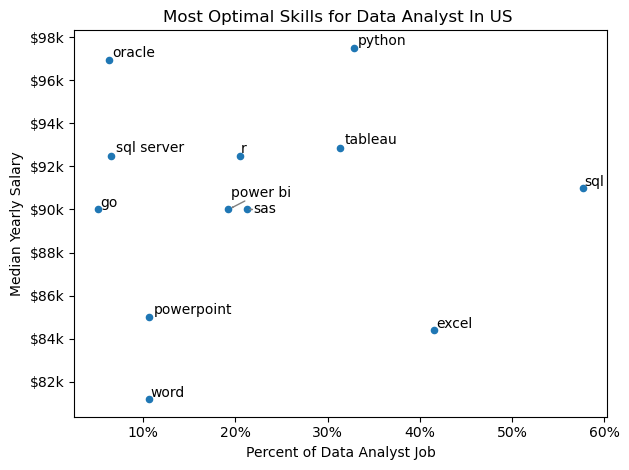

In [9]:
from adjustText import adjust_text

df_DA_skills_high_demand.plot(kind='scatter',x='skill_percent',y='median_salary')
plt.title('Most Optimal Skills for Data Analyst In US ')
plt.xlabel('Percent of Data Analyst Job')
plt.ylabel('Median Yearly Salary')

texts=[]
for skill_stat in df_DA_skills_high_demand.iterrows():
    texts.append(plt.text(skill_stat[1]['skill_percent'], skill_stat[1]['median_salary'],skill_stat[0])) 
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray')) 

ax=plt.gca() 
ax.yaxis.set_major_formatter(lambda x, pos:  f'${x/1000:.0f}k')
ax.xaxis.set_major_formatter(lambda x, pos:  f'{int(x)}%')
plt.tight_layout()

In [10]:
df_technology = df['job_type_skills'].copy()
df_technology = df_technology.drop_duplicates()
df_technology = df_technology.dropna()

In [11]:
df_technology

1         {'analyst_tools': ['power bi', 'tableau'], 'pr...
2         {'analyst_tools': ['dax'], 'cloud': ['azure'],...
3         {'cloud': ['aws'], 'libraries': ['tensorflow',...
4         {'cloud': ['oracle', 'aws'], 'other': ['ansibl...
5         {'cloud': ['gcp'], 'programming': ['python', '...
                                ...                        
785697    {'analyst_tools': ['power bi', 'tableau', 'wor...
785721    {'analyst_tools': ['looker', 'tableau', 'splun...
785725    {'cloud': ['bigquery'], 'libraries': ['gdpr'],...
785735    {'cloud': ['bigquery', 'aws'], 'libraries': ['...
785736    {'os': ['linux', 'unix'], 'other': ['kubernete...
Name: job_type_skills, Length: 177562, dtype: str

In [12]:
technology_dict = {}
for row in df_technology:
    row_dict=ast.literal_eval(row)
    for key,value in row_dict.items():
        if key in technology_dict:
            for single in value:
                if single not in technology_dict[key]:
                    technology_dict[key].append(single)
        else:
            technology_dict[key] = value

In [13]:
technology_dict

{'analyst_tools': ['power bi',
  'tableau',
  'dax',
  'excel',
  'powerpoint',
  'qlik',
  'sap',
  'looker',
  'word',
  'sas',
  'spss',
  'microstrategy',
  'cognos',
  'outlook',
  'splunk',
  'alteryx',
  'ssis',
  'sharepoint',
  'ms access',
  'visio',
  'datarobot',
  'ssrs',
  'spreadsheet',
  'sheets',
  'powerbi',
  'nuix',
  'msaccess',
  'esquisse'],
 'programming': ['r',
  'python',
  'sql',
  'nosql',
  'c#',
  'c++',
  'java',
  'matlab',
  'bash',
  'mongodb',
  'php',
  'go',
  'ruby',
  'javascript',
  'powershell',
  'apl',
  'scala',
  'mongo',
  'shell',
  'sas',
  'vba',
  'c',
  'html',
  'css',
  'lua',
  'perl',
  'golang',
  't-sql',
  'typescript',
  'sass',
  'visual basic',
  'solidity',
  'swift',
  'kotlin',
  'julia',
  'fortran',
  'no-sql',
  'groovy',
  'crystal',
  'rust',
  'assembly',
  'dart',
  'f#',
  'cobol',
  'objective-c',
  'vb.net',
  'elixir',
  'pascal',
  'lisp',
  'clojure',
  'delphi',
  'erlang',
  'haskell',
  'ocaml',
  'visualba

In [14]:
df_technology = pd.DataFrame(technology_dict.items(),columns=(['technology','skills']))
df_technology = df_technology.explode('skills')
df_technology

,technology,skills
0,analyst_tools,power bi
0,analyst_tools,tableau
0,analyst_tools,dax
0,analyst_tools,excel
0,analyst_tools,powerpoint
...,...,...
9,sync,webex
9,sync,wire
9,sync,mattermost
9,sync,google chat


In [15]:
df_DA_US_exploded

,count_skills,median_salary,skill_percent
job_skills,,,
sql,2508,91000.0,57.655172
excel,1808,84392.0,41.563218
python,1431,97500.0,32.896552
tableau,1364,92875.0,31.356322
sas,926,90000.0,21.287356
...,...,...,...
theano,1,100000.0,0.022989
typescript,1,65000.0,0.022989
vmware,1,147500.0,0.022989


In [16]:
df_plot=df_DA_skills_high_demand.merge(df_technology,how='left',left_on='job_skills',right_on='skills')

In [17]:
df_plot

,count_skills,median_salary,skill_percent,technology,skills
0,2508,91000.00,57.655172,programming,sql
1,1808,84392.00,41.563218,analyst_tools,excel
2,1431,97500.00,32.896552,programming,python
3,1364,92875.00,31.356322,analyst_tools,tableau
4,926,90000.00,21.287356,analyst_tools,sas
5,926,90000.00,21.287356,programming,sas
6,893,92500.00,20.528736,programming,r
7,838,90000.00,19.264368,analyst_tools,power bi
8,462,85000.00,10.620690,analyst_tools,powerpoint
9,461,81194.75,10.597701,analyst_tools,word


In [39]:
df_plot['skills'][1]

'excel'

4 [0.61221732 0.15671086]
5 [-0.41588638  0.44260244]


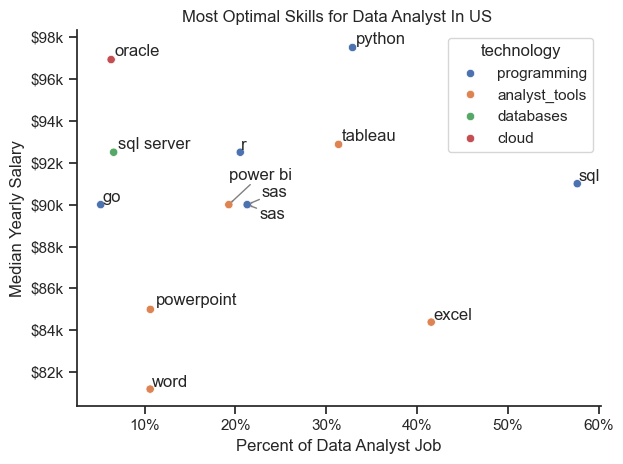

In [62]:
from adjustText import adjust_text

sns.scatterplot(data=df_plot,x='skill_percent',y='median_salary',hue='technology')
plt.title('Most Optimal Skills for Data Analyst In US ')
plt.xlabel('Percent of Data Analyst Job')
plt.ylabel('Median Yearly Salary')
sns.despine()
sns.set_theme(style='ticks')

texts=[]
for skill_stat in df_plot.iterrows():
    texts.append(plt.text(skill_stat[1]['skill_percent'], skill_stat[1]['median_salary'],skill_stat[1]['skills'])) 
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))

ax=plt.gca() 
ax.yaxis.set_major_formatter(lambda x, pos:  f'${x/1000:.0f}k')
ax.xaxis.set_major_formatter(lambda x, pos:  f'{int(x)}%')
plt.tight_layout()

plt.show()